<a href="https://colab.research.google.com/github/UKD1211/Macroeconomic_impact_of_gold-_Econ_growth/blob/main/Gold_price_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('default')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (14,6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

In [ ]:
df = pd.read_excel("/content/Master_Dataset.xlsx")

In [ ]:
df

In [ ]:
#sort dataset

df = df.sort_values("Date").reset_index(drop = True)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace = True)

In [ ]:
gold_price = df['Gold_Price[/10gm]']

In [ ]:
gold_price

In [ ]:
#gold_price_decompose

decomposition = seasonal_decompose(
    gold_price,
    model='additive',
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.suptitle(
    "Seasonal Decomposition of Gold Price",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [ ]:
# Monthly Gold Return (%)

df['Gold_Return_%'] = (
    df['Gold_Price[/10gm]']
    .pct_change() * 100
)

In [ ]:
gold_return = df['Gold_Return_%'].dropna()

In [ ]:
#Gold Return seasonal Decompose
decomposition_return = seasonal_decompose(
    gold_return,
    model='additive',
    period=12
)

fig = decomposition_return.plot()

fig.set_size_inches(16,10)

plt.suptitle(
    "Seasonal Decomposition of Gold Return",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

In [ ]:
#visual representation of the Stationarity check

In [ ]:
window = 12  # 12 months

rolling_mean = gold_price.rolling(window=window).mean()
rolling_std = gold_price.rolling(window=window).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(15,10),
    sharex=True,
    gridspec_kw={'hspace':0.15}
)

# -------------------------------
# Rolling Mean
# -------------------------------

axes[0].plot(
    gold_price,
    color='royalblue',
    linewidth=2,
    label='Gold Price'
)

axes[0].plot(
    rolling_mean,
    color='crimson',
    linewidth=2.5,
    label='12-Month Rolling Mean'
)

axes[0].set_title(
    'Gold Price with Rolling Mean',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Gold Price (₹/10gm)')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

# -------------------------------
# Rolling Standard Deviation
# -------------------------------

axes[1].plot(
    rolling_std,
    color='darkgreen',
    linewidth=2.5
)

axes[1].fill_between(
    rolling_std.index,
    rolling_std.values,
    color='limegreen',
    alpha=0.25
)

axes[1].set_title(
    '12-Month Rolling Standard Deviation',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_ylabel('Rolling Std')
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
window = 12

rolling_mean_return = gold_return.rolling(window=window).mean()
rolling_std_return = gold_return.rolling(window=window).std()

fig, axes = plt.subplots(
    2, 1,
    figsize=(15,10),
    sharex=True,
    gridspec_kw={'hspace':0.15}
)

# -------------------------------
# Rolling Mean
# -------------------------------

axes[0].plot(
    gold_return,
    color='royalblue',
    linewidth=2,
    label='Gold Return (%)'
)

axes[0].plot(
    rolling_mean_return,
    color='crimson',
    linewidth=2.5,
    label='12-Month Rolling Mean'
)

axes[0].axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

axes[0].set_title(
    'Gold Return with Rolling Mean',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Return (%)')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.3)

# -------------------------------
# Rolling Standard Deviation
# -------------------------------

axes[1].plot(
    rolling_std_return,
    color='darkgreen',
    linewidth=2.5
)

axes[1].fill_between(
    rolling_std_return.index,
    rolling_std_return.values,
    color='limegreen',
    alpha=0.25
)

axes[1].set_title(
    '12-Month Rolling Standard Deviation',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_ylabel('Rolling Std')
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

# Install once if not installed
!pip install arch

from arch.unitroot import PhillipsPerron

In [ ]:
def stationarity_tests(series, series_name):

    print("="*70)
    print(f"Stationarity Tests : {series_name}")
    print("="*70)

    # -----------------------------
    # ADF TEST
    # -----------------------------
    print("\nADF TEST")
    print("-"*30)

    adf_result = adfuller(series.dropna(), autolag='AIC')

    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"P-value       : {adf_result[1]:.4f}")
    print(f"Lags Used     : {adf_result[2]}")
    print(f"Observations  : {adf_result[3]}")

    print("\nCritical Values")

    for key, value in adf_result[4].items():
        print(f"{key}: {value:.4f}")

    if adf_result[1] < 0.05:
        print("\nConclusion : Reject H0 → Stationary")
    else:
        print("\nConclusion : Fail to Reject H0 → Non-Stationary")

    # -----------------------------
    # KPSS TEST
    # -----------------------------
    print("\n\nKPSS TEST")
    print("-"*30)

    kpss_result = kpss(series.dropna(),
                       regression='c',
                       nlags='auto')

    print(f"KPSS Statistic : {kpss_result[0]:.4f}")
    print(f"P-value        : {kpss_result[1]:.4f}")

    print("\nCritical Values")

    for key, value in kpss_result[3].items():
        print(f"{key}: {value}")

    if kpss_result[1] < 0.05:
        print("\nConclusion : Reject H0 → Non-Stationary")
    else:
        print("\nConclusion : Fail to Reject H0 → Stationary")

    # -----------------------------
    # PHILLIPS-PERRON
    # -----------------------------
    print("\n\nPHILLIPS-PERRON TEST")
    print("-"*30)

    pp = PhillipsPerron(series.dropna())

    print(pp.summary())

In [ ]:
stationarity_tests(
    gold_price,
    "Gold Price"
)

In [ ]:
stationarity_tests(
    gold_return,
    "Gold Return (%)"
)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15,10))

plot_acf(
    gold_return,
    lags=36,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title(
    "Autocorrelation Function (ACF) - Gold Return",
    fontsize=15,
    fontweight='bold'
)

plot_pacf(
    gold_return,
    lags=36,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) - Gold Return",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

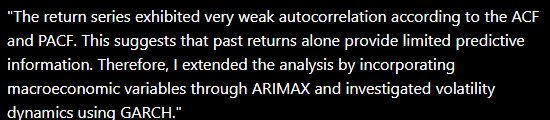

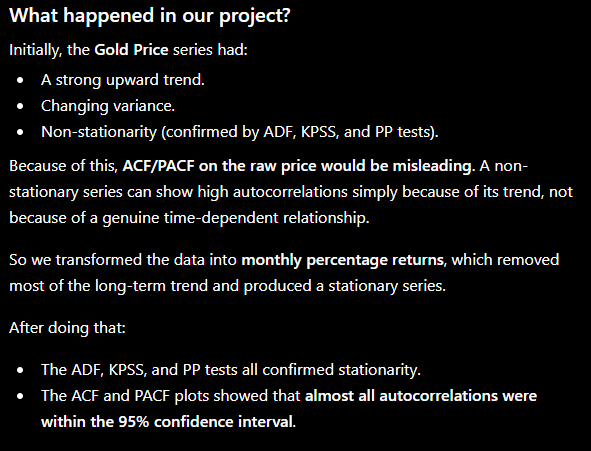

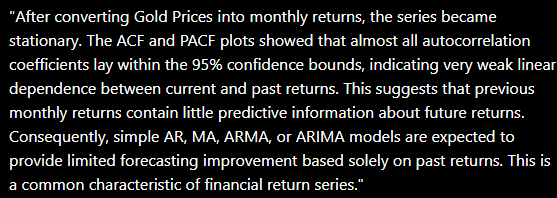

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15,10))

plot_acf(
    gold_price,
    lags=36,
    ax=axes[0],
    alpha=0.05
)

axes[0].set_title(
    "Autocorrelation Function (ACF) - Gold price",
    fontsize=15,
    fontweight='bold'
)

plot_pacf(
    gold_price,
    lags=36,
    ax=axes[1],
    method='ywm'
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) - Gold price",
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# **AR models**

In [ ]:
#AR models

from statsmodels.tsa.ar_model import AutoReg

ar_results = {}

for lag in [1,2,3,4,5,6]:

  model = AutoReg(
      gold_return,
      lags = lag,
      old_names = False
  ).fit()

  ar_results[lag] = model

  print("="*60)
  print(f"AR({lag})")
  print("="*60)

  print(model.summary())

  print("\nAIC :", round(model.aic,2))
  print("BIC :", round(model.bic,2))

# **Taken AR(1) model : Yt = 0.9853 + 0.1563*Yt-1**

In [ ]:
ar1 = AutoReg(
    gold_return,
    lags = 1,
    old_names = False
).fit()

In [ ]:
print(ar1.summary())

In [ ]:
fitted = ar1.fittedvalues

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    gold_return,
    label='Actual Gold Return',
    linewidth=2,
    color='royalblue'
)

plt.plot(
    fitted,
    label='AR(1) Fitted',
    linewidth=2,
    color='crimson'
)

plt.title(
    'Gold Return vs AR(1) Fitted Values',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Monthly Return (%)')

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
residuals = ar1.resid

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    residuals,
    color='darkgreen',
    linewidth=1.8
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title(
    'Residuals of AR(1)',
    fontsize=16,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        gold_return.iloc[1:],   # first value has no prediction
        fitted
    )
)

mae = mean_absolute_error(
    gold_return.iloc[1:],
    fitted
)

mape = mean_absolute_percentage_error(
    gold_return.iloc[1:],
    fitted
)

print("MAPE :", mape)

print("RMSE :", rmse)
print("MAE  :", mae)

# **MA models**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

for lags in [1,2,3,4,5]:
  model = ARIMA(
      gold_return,
      order = (0,0,lags),
      enforce_stationarity = False,
      enforce_invertibility = False
  ).fit()

  print("="*60)
  print(f"MA({lags})")
  print("="*60)

  print(model.summary())
  print("\nAIC :", round(model.aic,2))
  print("BIC :", round(model.bic,2))

In [ ]:
ma4 = ARIMA(
    gold_return,
    order = (0,0,4),
    enforce_stationarity = False,
    enforce_invertibility = False
).fit()
print(ma4.summary())

In [ ]:
ma4_fitted = ma4.fittedvalues

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    gold_return,
    label='Actual Gold Return',
    color='royalblue',
    linewidth=2
)

plt.plot(
    ma4_fitted,
    label='MA Fitted',
    color='crimson',
    linewidth=2
)

plt.legend()

plt.grid(alpha=0.3)

plt.title("Gold Return vs MA(4) Fitted Values",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()

plt.show()

In [ ]:
residuals = ma4.resid

plt.figure(figsize=(16,5))

plt.plot(
    residuals,
    color='darkgreen'
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.grid(alpha=0.3)

plt.title(
    "Residuals of MA(4) Model",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        gold_return,
        ma4_fitted
    )
)

mae = mean_absolute_error(
    gold_return,
    ma4_fitted
)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# **ARMA models**

In [ ]:
arma_orders = [
    (1,1),
    (1,2),
    (1,3),
    (1,4),
    (2,1),
    (2,2),
    (2,4),
    (3,1),
    (3,2),
    (3,4)
]

from statsmodels.tsa.arima.model import ARIMA

arma_models = {}

for p, q in arma_orders:

    print("="*70)
    print(f"ARMA({p},{q})")
    print("="*70)

    model = ARIMA(
        gold_return,
        order=(p,0,q)      # d = 0 because returns are stationary
    ).fit()

    arma_models[(p,q)] = model

    print(model.summary())

    print(f"\nAIC : {model.aic:.2f}")
    print(f"BIC : {model.bic:.2f}")

In [ ]:
ARMA_11 = ARIMA(
    gold_return,
    order = (1,0,1)
).fit()

print(ARMA_11.summary())

In [ ]:
fitted = ARMA_11.fittedvalues

plt.figure(figsize=(16,6))

plt.plot(
    gold_return,
    label="Actual",
    color="royalblue",
    linewidth=2
)

plt.plot(
    fitted,
    label="ARMA Fitted",
    color="crimson",
    linewidth=2
)

plt.legend()

plt.grid(alpha=0.3)

plt.title(
    "Gold Return vs ARMA(1,1) Fitted Values",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
residuals = ARMA_11.resid

plt.figure(figsize=(16,5))

plt.plot(
    residuals,
    color="darkgreen"
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.grid(alpha=0.3)

plt.title(
    "Residuals of ARMA",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(gold_return, fitted))
mae = mean_absolute_error(gold_return, fitted)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

In [ ]:
gold_price = df['Gold_Price[/10gm]'].copy()

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    gold_price,
    color='darkgoldenrod',
    linewidth=2
)

plt.title(
    'Monthly Gold Price',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Year")
plt.ylabel("Price (₹ / 10 gm)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

# ----------------------------
# ADF
# ----------------------------

adf = adfuller(gold_price)

print("ADF Statistic :", adf[0])
print("p-value :", adf[1])

# ----------------------------
# KPSS
# ----------------------------

kpss_test = kpss(
    gold_price,
    regression='c',
    nlags='auto'
)

print("\nKPSS Statistic :", kpss_test[0])
print("p-value :", kpss_test[1])

In [ ]:
gold_price_diff = gold_price.diff().dropna()

In [ ]:
from statsmodels.tsa.stattools import adfuller,kpss
adf = adfuller(gold_price_diff)

print("ADF :", adf[0])
print("p-value :", adf[1])

kpss_test = kpss(
    gold_price_diff,
    regression='c',
    nlags='auto'
)

print("KPSS :", kpss_test[0])
print("p-value :", kpss_test[1])

In [ ]:
gold_2nd_diff = gold_price.diff().diff().dropna()

In [ ]:
adf = adfuller(gold_2nd_diff)

print("ADF :", adf[0])
print("p-value :", adf[1])

kpss_test = kpss(
    gold_2nd_diff,
    regression='c',
    nlags='auto'
)

print("KPSS :", kpss_test[0])
print("p-value :", kpss_test[1])

In [ ]:
gold_2nd_diff

In [ ]:
plt.plot(gold_2nd_diff)

# **Structural Break Analysis**

In [ ]:
window = 24      # 24 months = 2 years

rolling_mean = gold_price.rolling(window).mean()

plt.figure(figsize=(15,5))

plt.plot(gold_price,label="Gold Price",lw=2)

plt.plot(
    rolling_mean,
    color='red',
    lw=2,
    label=f'{window}-Month Rolling Mean'
)

plt.title("Rolling Mean")
plt.legend()
plt.grid(alpha=.3)

plt.show()

In [ ]:
rolling_std = gold_price.rolling(window).std()

plt.figure(figsize=(15,5))

plt.plot(
    rolling_std,
    color='green',
    lw=2
)

plt.title("Rolling Standard Deviation")

plt.grid(alpha=.3)

plt.show()

In [ ]:
from scipy.stats import linregress

window = 24

slopes = []

dates = []

for i in range(window, len(gold_price)):

    y = gold_price.iloc[i-window:i]

    x = np.arange(window)

    slope = linregress(x,y).slope

    slopes.append(slope)

    dates.append(gold_price.index[i])

plt.figure(figsize=(15,5))

plt.plot(
    dates,
    slopes,
    color='purple'
)

plt.axhline(
    0,
    color='red',
    ls='--'
)

plt.title("Rolling Trend (Slope)")

plt.grid(alpha=.3)

plt.show()

# **fitted a simple linear trend model**

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import breaks_cusumolsresid

X = np.ones(len(gold_price))

model = sm.OLS(
    gold_price.values,
    X
).fit()

cusum = breaks_cusumolsresid(
    model.resid
)

print("CUSUM Statistic :", cusum[0])
print("p-value :", cusum[1])

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Time Index
time = np.arange(len(gold_price))

X = sm.add_constant(time)

model = sm.OLS(gold_price, X).fit()

fitted = model.fittedvalues

plt.figure(figsize=(16,6))

plt.plot(
    gold_price.index,
    gold_price,
    label="Actual Gold Price",
    linewidth=2,
    color='gold'
)

plt.plot(
    gold_price.index,
    fitted,
    label="Linear Trend",
    color='red',
    linewidth=3
)

plt.title("Actual Gold Price vs Estimated Linear Trend")

plt.legend()

plt.grid(alpha=.3)

plt.show()

In [ ]:
residuals = model.resid

plt.figure(figsize=(16,5))

plt.plot(
    gold_price.index,
    residuals,
    color='navy'
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title("Residuals from Linear Trend")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

In [ ]:
cum_residuals = residuals.cumsum()

plt.figure(figsize=(16,5))

plt.plot(
    gold_price.index,
    cum_residuals,
    color='purple',
    linewidth=2
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title("Cumulative Sum of Residuals")

plt.grid(alpha=.3)

plt.show()

# **Finding Structural Break points**

In [ ]:
!pip install ruptures

In [ ]:
import ruptures as rpt

signal = gold_price.values

algo = rpt.Pelt(
    model="rbf"
).fit(signal)

breaks = algo.predict(
    pen=10
)

print(breaks)

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    gold_price,
    lw=2
)

for bp in breaks[:-1]:

    plt.axvline(
        gold_price.index[bp],
        color='red',
        ls='--'
    )

plt.title("Detected Structural Breaks")

plt.grid(alpha=.3)

plt.show()

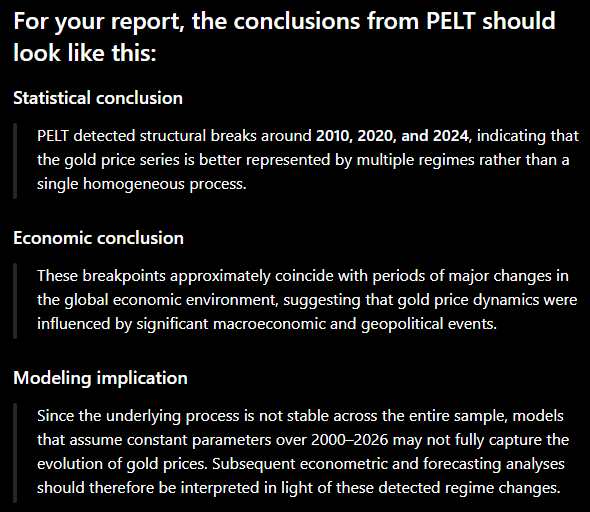

In [ ]:
bp = breaks[0]
before = gold_price.iloc[:bp]

after = gold_price.iloc[bp:]

print("Before Break")

print(before.describe())

print()

print("After Break")

print(after.describe())

In [ ]:
print("Variance Before :",before.var())

print("Variance After :",after.var())

In [ ]:
print("Mean Before :",before.mean())

print("Mean After :",after.mean())

In [ ]:
from scipy.stats import linregress

x=np.arange(len(before))

print(
    "Slope Before :",
    linregress(x,before).slope
)

x=np.arange(len(after))

print(
    "Slope After :",
    linregress(x,after).slope
)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Re-load df and preprocess it as it was likely not defined in the current session
df = pd.read_excel("/content/Master_Dataset.xlsx")
df = df.sort_values("Date").reset_index(drop = True)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace = True)

# PELT breakpoints
breaks = [125, 240, 290, 315]

summary = []

start = 0

for i, bp in enumerate(breaks):

    segment = df.iloc[start:bp]

    y = segment["Gold_Price[/10gm]"].values
    x = np.arange(len(y))

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    growth = ((y[-1] - y[0]) / y[0]) * 100

    summary.append({

        "Regime": f"R{i+1}",

        "Period":
        f"{segment.index[0].strftime('%b-%Y')} → {segment.index[-1].strftime('%b-%Y')}",

        "Obs": len(segment),

        "Mean Price": round(y.mean(),2),

        "Median": round(np.median(y),2),

        "Std Dev": round(y.std(),2),

        "Min": round(y.min(),2),

        "Max": round(y.max(),2),

        "Trend (₹/Month)": round(slope,2),

        "Growth (%)": round(growth,2),

        "R²": round(r_value**2,3)

    })

    start = bp


summary_table = pd.DataFrame(summary)

summary_table

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# PELT breakpoints
breaks = [125, 240, 290, 315]

colors = [
    "#E8F4FA",
    "#FFF3CD",
    "#D4EDDA",
    "#F8D7DA"
]

fig, ax = plt.subplots(figsize=(18,8))

# Plot actual Gold Price
ax.plot(
    df.index,
    df["Gold_Price[/10gm]"],
    color="navy",
    linewidth=2.5,
    label="Actual Gold Price"
)

start = 0

for i, bp in enumerate(breaks):

    segment = df.iloc[start:bp]

    y = segment["Gold_Price[/10gm]"].values
    x = np.arange(len(y))

    # OLS Trend
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    trend = intercept + slope*x

    # Plot regime trend
    ax.plot(
        segment.index,
        trend,
        color="red",
        linestyle="--",
        linewidth=3,
        label="OLS Trend" if i==0 else ""
    )

    # Shade regime
    ax.axvspan(
        segment.index[0],
        segment.index[-1],
        color=colors[i],
        alpha=0.18
    )

    # Regime Label
    mid = segment.index[len(segment)//2]

    ax.text(
        mid,
        df["Gold_Price[/10gm]"].max()*0.96,
        f"Regime {i+1}",
        fontsize=13,
        weight="bold",
        ha="center"
    )

    # Breakpoint line
    if bp < len(df):

        ax.axvline(
            df.index[bp],
            color="black",
            linestyle=":",
            linewidth=2
        )

    start = bp

plt.title(
    "Structural Regimes Detected by PELT with Separate OLS Trends",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year", fontsize=13)
plt.ylabel("Gold Price (₹ / 10 gm)", fontsize=13)

plt.legend(fontsize=11)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

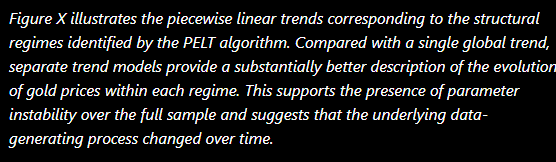

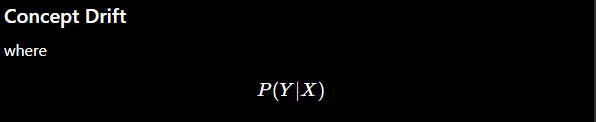

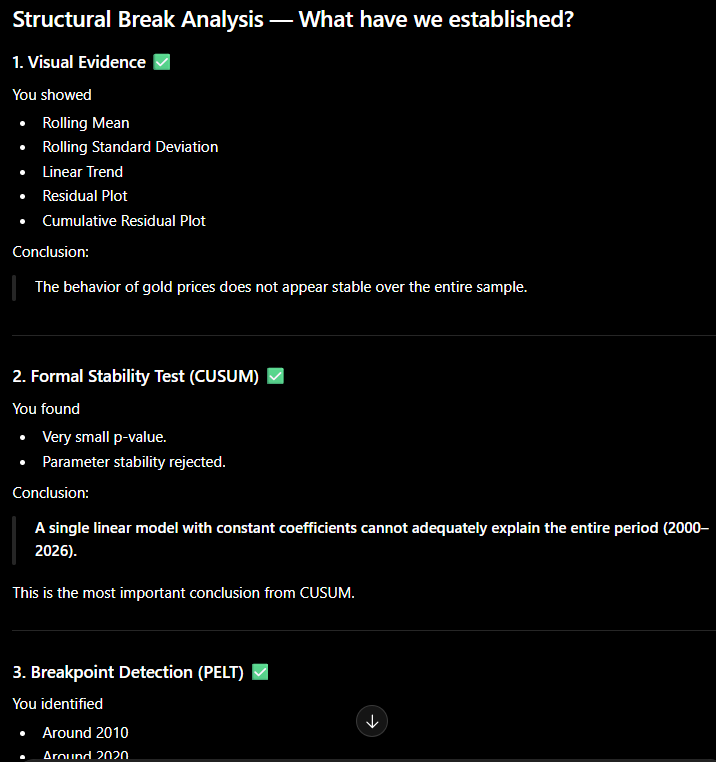

# **CoIntegration Test**

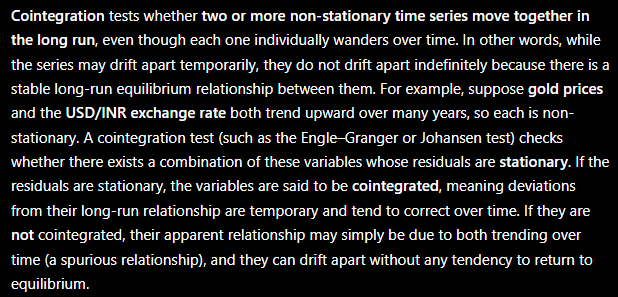

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint

# -------------------------------
# Variables for Cointegration Test
# -------------------------------

variables = [
    "Gold_Price[/10gm]",                          # Target
    "USDINR",
    "Overall_CPI",
    "Inflation_YoY",
    "Repo_Rate",
    "FPI_Net_INR_Crore",
    "Real GDP growth (Annual percent change)",
    "GDP, current prices (Billions of U.S. dollars)",
    "Gold_Reservs_USD_mn"  # Corrected column name
]

# -------------------------------
# Clean Data
# -------------------------------

coin_df = df[variables].copy()

coin_df = coin_df.replace("---", np.nan)

coin_df = coin_df.apply(pd.to_numeric, errors="coerce")

# -------------------------------
# Engle-Granger Cointegration
# -------------------------------

target = "Gold_Price[/10gm]"

results = []

for col in coin_df.columns:

    if col == target:
        continue

    temp = coin_df[[target, col]].dropna()

    if len(temp) < 50:
        continue

    score, pvalue, critical = coint(
        temp[target],
        temp[col]
    )

    results.append({

        "Variable": col,
        "Observations": len(temp),
        "Test Statistic": round(score,3),
        "5% Critical": round(critical[1],3),
        "P-value": round(pvalue,4),
        "Cointegrated": "Yes" if pvalue < 0.05 else "No"

    })

cointegration_results = (
    pd.DataFrame(results)
      .sort_values("P-value")
      .reset_index(drop=True)
)

cointegration_results

In [ ]:
from statsmodels.tsa.stattools import adfuller

def integration_order(series, name):

    series = series.dropna()

    # -----------------
    # Level
    # -----------------
    p0 = adfuller(series, autolag='AIC')[1]

    # -----------------
    # First Difference
    # -----------------
    p1 = adfuller(series.diff().dropna(), autolag='AIC')[1]

    # -----------------
    # Second Difference
    # -----------------
    p2 = adfuller(series.diff().diff().dropna(), autolag='AIC')[1]

    if p0 < 0.05:
        order = "I(0)"
    elif p1 < 0.05:
        order = "I(1)"
    elif p2 < 0.05:
        order = "I(2)"
    else:
        order = "> I(2)"

    return {
        "Variable": name,
        "ADF(Level)": round(p0,4),
        "ADF(1st Diff)": round(p1,4),
        "ADF(2nd Diff)": round(p2,4),
        "Integration Order": order
    }

In [ ]:
variables = [
    "Gold_Price[/10gm]",
    "USDINR",
    "Overall_CPI",
    "Inflation_YoY",
    "Repo_Rate",
    "FPI_Net_INR_Crore",
    "Real GDP growth (Annual percent change)",
    "GDP, current prices (Billions of U.S. dollars)",
    "Gold_Reservs_USD_mn"
]

results = []

for col in variables:

    s = pd.to_numeric(df[col], errors="coerce")

    results.append(
        integration_order(s, col)
    )

integration_table = pd.DataFrame(results)

integration_table

In [ ]:
import pandas as pd
import numpy as np

coin_df = pd.DataFrame(index=df.index)

# Target
coin_df["Log_Gold"] = np.log(pd.to_numeric(df["Gold_Price[/10gm]"], errors="coerce"))

# Positive level variables
coin_df["Log_USDINR"] = np.log(pd.to_numeric(df["USDINR"], errors="coerce"))

coin_df["Log_CPI"] = np.log(pd.to_numeric(df["Overall_CPI"], errors="coerce"))

coin_df["Log_GDP"] = np.log(
    pd.to_numeric(df["GDP, current prices (Billions of U.S. dollars)"], errors="coerce")
)

coin_df["Log_GoldReserves"] = np.log(
    pd.to_numeric(df["Gold_Reservs_USD_mn"], errors="coerce")
)

# Already rates (%)
coin_df["Inflation_YoY"] = pd.to_numeric(
    df["Inflation_YoY"],
    errors="coerce"
)

coin_df["Repo_Rate"] = pd.to_numeric(
    df["Repo_Rate"],
    errors="coerce"
)

coin_df["GDP_Growth"] = pd.to_numeric(
    df["Real GDP growth (Annual percent change)"],
    errors="coerce"
)

# FPI can be negative, so don't log
coin_df["FPI"] = pd.to_numeric(
    df["FPI_Net_INR_Crore"],
    errors="coerce"
)

In [ ]:
from statsmodels.tsa.stattools import adfuller

def integration_order(series):

    series = series.dropna()

    p0 = adfuller(series, autolag="AIC")[1]
    p1 = adfuller(series.diff().dropna(), autolag="AIC")[1]
    p2 = adfuller(series.diff().diff().dropna(), autolag="AIC")[1]

    if p0 < 0.05:
        order = "I(0)"
    elif p1 < 0.05:
        order = "I(1)"
    elif p2 < 0.05:
        order = "I(2)"
    else:
        order = ">I(2)"

    return p0, p1, p2, order


results = []

for col in coin_df.columns:

    p0, p1, p2, order = integration_order(coin_df[col])

    results.append({

        "Variable": col,

        "ADF(Level)": round(p0,4),

        "ADF(1st Diff)": round(p1,4),

        "ADF(2nd Diff)": round(p2,4),

        "Integration": order

    })

integration_table = pd.DataFrame(results)

integration_table

In [ ]:
from statsmodels.tsa.stattools import coint

target = "Log_Gold"

results = []

for col in coin_df.columns:

    if col == target:
        continue

    temp = coin_df[[target, col]].dropna()

    if len(temp) < 50:
        continue

    score, pvalue, critical = coint(
        temp[target],
        temp[col]
    )

    results.append({

        "Variable": col,

        "Observations": len(temp),

        "Test Statistic": round(score,3),

        "5% Critical": round(critical[1],3),

        "P-value": round(pvalue,4),

        "Cointegrated": "Yes" if pvalue < 0.05 else "No"

    })

cointegration_results = (
    pd.DataFrame(results)
      .sort_values("P-value")
      .reset_index(drop=True)
)

cointegration_results

In [ ]:
import numpy as np

log_gold = np.log(gold_price)

print("Level:", adfuller(log_gold)[1])
print("1st Diff:", adfuller(log_gold.diff().dropna())[1])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

log_gold = np.log(df["Gold_Price[/10gm]"])

log_gold_diff = log_gold.diff().dropna()

plt.figure(figsize=(15,5))

plt.plot(
    log_gold_diff,
    color="darkblue",
    linewidth=1.8
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.title("First Difference of Log Gold Price (Log Returns)", fontsize=15)

plt.ylabel("Δ log(Gold Price)")

plt.xlabel("Year")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

gold = df["Gold_Price[/10gm]"]

log_gold = np.log(gold)

gold_diff = gold.diff()

log_gold_diff = log_gold.diff()

fig, ax = plt.subplots(2,2, figsize=(16,10))

# ------------------------
ax[0,0].plot(gold)
ax[0,0].set_title("Original Gold Price")
ax[0,0].grid(alpha=.3)

# ------------------------
ax[0,1].plot(gold_diff)
ax[0,1].axhline(0,color='red',ls='--')
ax[0,1].set_title("First Difference")
ax[0,1].grid(alpha=.3)

# ------------------------
ax[1,0].plot(log_gold,color="green")
ax[1,0].set_title("Log Gold Price")
ax[1,0].grid(alpha=.3)

# ------------------------
ax[1,1].plot(log_gold_diff,color="purple")
ax[1,1].axhline(0,color='red',ls='--')
ax[1,1].set_title("First Difference of Log Gold Price")
ax[1,1].grid(alpha=.3)

plt.tight_layout()

plt.show()

# **Granger Causality test**

In [ ]:
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
variables = [

"USDINR",

"Overall_CPI",

"Inflation_YoY",

"Repo_Rate",

"FPI_Net_INR_Crore",

"Real GDP growth (Annual percent change)",

"GDP, current prices (Billions of U.S. dollars)",

"Gold_Reservs_USD_mn",

 'Remittances received (Personal remittances received current U.S. $)'

]

target = "Gold_Price[/10gm]"

In [ ]:
results = []

for var in variables:

    temp = df[[target,var]].copy()

    temp = temp.apply(pd.to_numeric, errors="coerce")

    temp = temp.dropna()

    print("="*80)
    print(f"{var}  --->  Gold Price")
    print("="*80)

    test = grangercausalitytests(
        temp[[target,var]],
        maxlag=12,
        verbose=False
    )

    best_p = 1

    best_lag = None

    for lag in range(1,13):

        p = test[lag][0]["ssr_ftest"][1]

        if p < best_p:

            best_p = p

            best_lag = lag

    results.append({

        "Variable":var,

        "Best Lag":best_lag,

        "Minimum p-value":round(best_p,4),

        "Granger Cause":"Yes" if best_p<0.05 else "No"

    })

granger_table = pd.DataFrame(results)

granger_table.sort_values("Minimum p-value")

In [ ]:
import matplotlib.pyplot as plt

fig,ax1=plt.subplots(figsize=(14,5))

ax1.plot(df.index,df[target],label="Gold Price",color="gold")

ax2=ax1.twinx()

ax2.plot(df.index,df["USDINR"],label="USDINR",color="red")

plt.title("Gold Price and USDINR")

plt.show()

# ARIMA (Gold Price)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from itertools import product

import warnings
warnings.filterwarnings("ignore")

In [ ]:
gold = df["Gold_Price[/10gm]"]

gold = gold.dropna()

gold.index = pd.to_datetime(gold.index)

In [ ]:
train = gold[:-24]

test = gold[-24:]

print(len(train), len(test))

In [ ]:
best_aic = np.inf

best_order = None

best_model = None

p = range(0,4)
d = range(0,3)
q = range(0,4)

for order in product(p,d,q):

    try:

        model = ARIMA(train, order=order)

        fitted = model.fit()

        if fitted.aic < best_aic:

            best_aic = fitted.aic

            best_order = order

            best_model = fitted

    except:
        continue

print("Best Order :", best_order)

print("Best AIC :", best_aic)

In [ ]:
print(best_model.summary())

In [ ]:
forecast = best_model.forecast(
    steps=len(test)
)

forecast = pd.Series(
    forecast,
    index=test.index
)

In [ ]:
rmse = np.sqrt(
    mean_squared_error(test,forecast)
)

mae = mean_absolute_error(
    test,
    forecast
)

mape = mean_absolute_percentage_error(
    test,
    forecast
)*100

print(f"RMSE : {rmse:.2f}")

print(f"MAE  : {mae:.2f}")

print(f"MAPE : {mape:.2f}%")

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Train",
    linewidth=2
)

plt.plot(
    test,
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast,
    label="Forecast",
    linewidth=2,
    linestyle="--"
)

plt.title("ARIMA Forecast of Gold Price")

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.legend()

plt.grid(alpha=.3)

plt.show()

In [ ]:
residuals = best_model.resid

plt.figure(figsize=(15,4))

plt.plot(residuals)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("ARIMA Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=30
)

plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

lb

In [ ]:
arima_results = {

    "Model":"ARIMA",

    "Order":best_order,

    "AIC":best_model.aic,

    "BIC":best_model.bic,

    "RMSE":rmse,

    "MAE":mae,

    "MAPE":mape

}

arima_results

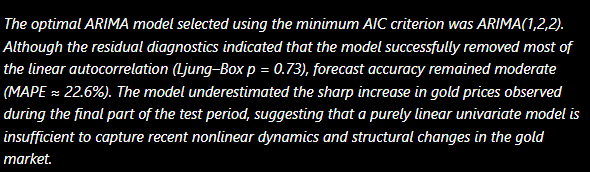

# **Holt-Winters Exponential Smoothing**

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

import numpy as np

gold = df["Gold_Price[/10gm]"].dropna()

train = gold[:-24]

test = gold[-24:]

model = ExponentialSmoothing(

    train,

    trend="add",

    seasonal=None

)

fit = model.fit(
    optimized=True
)

forecast = fit.forecast(
    len(test)
)

forecast = pd.Series(
    forecast,
    index=test.index
)

In [ ]:
rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mae = mean_absolute_error(
    test,
    forecast
)

mape = mean_absolute_percentage_error(
    test,
    forecast
)*100

print(f"RMSE : {rmse:.2f}")

print(f"MAE  : {mae:.2f}")

print(f"MAPE : {mape:.2f}%")

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    train,
    label="Train (Actual)",
    color="steelblue",
    linewidth=2
)

plt.plot(
    fit.fittedvalues,
    label="Train (Fitted)",
    color="yellow",
    linewidth=2
)

plt.plot(
    test,
    label="Test (Actual)",
    color="orange",
    linewidth=2
)

plt.plot(
    forecast,
    label="Forecast",
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Holt-Winters: Actual vs Fitted vs Forecast")

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.grid(alpha=.3)

plt.legend()

plt.show()

In [ ]:
residuals = train - fit.fittedvalues

plt.figure(figsize=(15,4))

plt.plot(residuals)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Holt-Winters Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Holt-Winters Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(
    residuals.dropna(),
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))

plot_acf(
    residuals.dropna(),
    lags=30
)

plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(

    residuals,

    lags=[10],

    return_df=True

)

lb

In [ ]:
holt_results = {

    "Model":"Holt-Winters",

    "RMSE":rmse,

    "MAE":mae,

    "MAPE":mape

}

holt_results

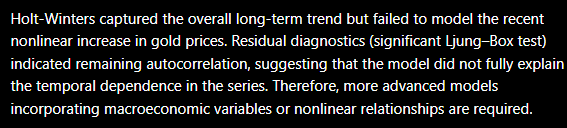

# **ARIMAX**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from statsmodels.graphics.tsaplots import plot_acf

from statsmodels.stats.diagnostic import acorr_ljungbox

import scipy.stats as stats

target = "Gold_Price[/10gm]"

features = [

    "USDINR",

    # "Overall_CPI",

    "Inflation_YoY",

    "GDP, current prices (Billions of U.S. dollars)",

    "FPI_Net_INR_Crore",

    "Gold_Reservs_USD_mn",

]

data = df[[target]+features].copy()

data = data.apply(pd.to_numeric,errors="coerce")

data = data.dropna()

data.head()

In [ ]:
train = data.iloc[:-24]

test = data.iloc[-24:]

y_train = train[target]

y_test = test[target]

X_train = train[features]

X_test = test[features]

In [ ]:
model = SARIMAX(

    y_train,

    exog=X_train,

    order=(1,2,2),

    seasonal_order=(0,0,0,0),

    enforce_stationarity=False,

    enforce_invertibility=False

)

fit = model.fit()

print(fit.summary())

In [ ]:
train_fit = fit.fittedvalues

forecast = fit.forecast(

    steps=len(test),

    exog=X_test

)

forecast = pd.Series(

    forecast,

    index=y_test.index

)

In [ ]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        forecast

    )

)

mae = mean_absolute_error(

    y_test,

    forecast

)

mape = mean_absolute_percentage_error(

    y_test,

    forecast

)*100

print("RMSE :",rmse)

print("MAE :",mae)

print("MAPE :",mape)

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(

    y_train,

    label="Train",

    linewidth=2

)

plt.plot(

    train_fit,

    label="Train Fitted",

    linewidth=2

)

plt.plot(

    y_test,

    label="Actual",

    linewidth=2

)

plt.plot(

    forecast,

    "--",

    label="Forecast",

    linewidth=2

)

plt.title("ARIMAX Forecast")

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.grid(alpha=.3)

plt.legend()

plt.show()

In [ ]:
residuals = fit.resid

plt.figure(figsize=(15,4))

plt.plot(residuals)

plt.axhline(

    0,

    color="red",

    linestyle="--"

)

plt.title("ARIMAX Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(

    residuals,

    bins=30,

    edgecolor="black"

)

plt.title("Residual Distribution")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plot_acf(

    residuals.dropna(),

    lags=30

)

plt.show()

In [ ]:
stats.probplot(

    residuals.dropna(),

    dist="norm",

    plot=plt

)

plt.title("QQ Plot")

plt.grid(alpha=.3)

plt.show()

In [ ]:
lb = acorr_ljungbox(

    residuals,

    lags=[10],

    return_df=True

)

lb

In [ ]:
arimax_results = {

    "Model":"ARIMAX",

    "Order":(1,2,2),

    "AIC":fit.aic,

    "BIC":fit.bic,

    "RMSE":rmse,

    "MAE":mae,

    "MAPE":mape

}

arimax_results

In [ ]:
coef_table = pd.DataFrame({

    "Coefficient":fit.params,

    "P-value":fit.pvalues

})

coef_table

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data[features].copy()

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

# **SARIMAX**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from statsmodels.graphics.tsaplots import plot_acf

from statsmodels.stats.diagnostic import acorr_ljungbox

import scipy.stats as stats

target = "Gold_Price[/10gm]"

features = [

    "USDINR",

    "Inflation_YoY",

    "GDP, current prices (Billions of U.S. dollars)",

    "FPI_Net_INR_Crore",

    "Gold_Reservs_USD_mn"

]

data = df[[target]+features].copy()

data = data.apply(pd.to_numeric,errors="coerce")

data = data.dropna()

train = data.iloc[:-24]

test = data.iloc[-24:]

y_train = train[target]

y_test = test[target]

X_train = train[features]

X_test = test[features]

In [ ]:
seasonal_orders = [
    (0,0,0,12),
    (1,0,0,12),
    (0,0,1,12),
    (1,0,1,12),
    (1,1,1,12),
    (0,1,1,12)
]

results = []

for s_order in seasonal_orders:

    try:

        model = SARIMAX(

            y_train,

            exog=X_train,

            order=(1,2,2),

            seasonal_order=s_order,

            enforce_stationarity=False,

            enforce_invertibility=False

        )

        fit = model.fit(disp=False)

        forecast = fit.forecast(

            steps=len(y_test),

            exog=X_test

        )

        rmse = np.sqrt(mean_squared_error(y_test, forecast))

        mae = mean_absolute_error(y_test, forecast)

        mape = mean_absolute_percentage_error(y_test, forecast)*100

        results.append({

            "Seasonal Order":s_order,

            "AIC":fit.aic,

            "BIC":fit.bic,

            "RMSE":rmse,

            "MAE":mae,

            "MAPE":mape

        })

    except:

        continue

seasonal_results = pd.DataFrame(results)

seasonal_results.sort_values("RMSE")

In [ ]:
model = SARIMAX(

    y_train,

    exog=X_train,

    order=(1,2,2),

    seasonal_order=(0,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

fit = model.fit()

print(fit.summary())

In [ ]:
train_fit = fit.fittedvalues

forecast = fit.forecast(

    steps=len(test),

    exog=X_test

)

forecast = pd.Series(

    forecast,

    index=y_test.index

)

In [ ]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        forecast

    )

)

mae = mean_absolute_error(

    y_test,

    forecast

)

mape = mean_absolute_percentage_error(

    y_test,

    forecast

)*100

print("RMSE :",rmse)

print("MAE :",mae)

print("MAPE :",mape)

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(

    y_train,

    label="Train",

    lw=2

)

plt.plot(

    train_fit,

    label="Train Fitted",

    lw=2

)

plt.plot(

    y_test,

    label="Actual",

    lw=2

)

plt.plot(

    forecast,

    "--",

    label="Forecast",

    lw=2

)

plt.title("SARIMAX Forecast")

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.grid(alpha=.3)

plt.legend()

plt.show()

In [ ]:
residuals = fit.resid

plt.figure(figsize=(15,4))

plt.plot(residuals)

plt.axhline(

0,

color="red",

ls="--"

)

plt.title("SARIMAX Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(

residuals,

bins=30,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plot_acf(

residuals.dropna(),

lags=30

)

plt.show()

In [ ]:
lb = acorr_ljungbox(

residuals,

lags=[10],

return_df=True

)

lb

In [ ]:
coef_table = pd.DataFrame({

"Coefficient":fit.params,

"P-value":fit.pvalues

})

coef_table

In [ ]:
sarimax_results = {

"Model":"SARIMAX",

"Order":(1,2,2),

"Seasonal Order":(0,1,1,12),

"AIC":fit.aic,

"BIC":fit.bic,

"RMSE":rmse,

"MAE":mae,

"MAPE":mape

}

sarimax_results

In [ ]:
comparison = pd.DataFrame([

arima_results,

holt_results,

arimax_results,

sarimax_results

])

comparison

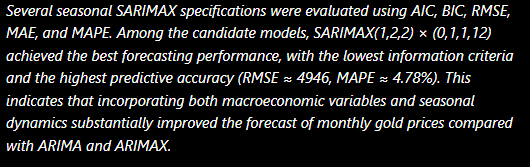

# Multimple Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

df_ml = df.copy()

df_ml["Lag1"] = df_ml["Gold_Price[/10gm]"].shift(1)
df_ml["Lag2"] = df_ml["Gold_Price[/10gm]"].shift(2)
df_ml["Lag3"] = df_ml["Gold_Price[/10gm]"].shift(3)
df_ml["Lag6"] = df_ml["Gold_Price[/10gm]"].shift(6)
df_ml["Lag12"] = df_ml["Gold_Price[/10gm]"].shift(12)

In [ ]:
features = [

    "Lag1",
    "Lag2",
    "Lag3",
    "Lag6",
    "Lag12",

    "USDINR",

    "Inflation_YoY",

    "GDP, current prices (Billions of U.S. dollars)",

    "FPI_Net_INR_Crore",

    "Gold_Reservs_USD_mn"

]

target = "Gold_Price[/10gm]"

data = df_ml[features+[target]].copy()

data = data.apply(pd.to_numeric, errors="coerce")

data = data.dropna()

In [ ]:
train = data.iloc[:-24]

test = data.iloc[-24:]

X_train = train[features]

X_test = test[features]

y_train = train[target]

y_test = test[target]

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

train_pred = model.predict(X_train)

forecast = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, forecast))

mae = mean_absolute_error(y_test, forecast)

mape = mean_absolute_percentage_error(y_test, forecast)*100

r2 = r2_score(y_test, forecast)

print("RMSE :", rmse)
print("MAE :", mae)
print("MAPE :", mape)
print("R² :", r2)

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train.index,
    y_train,
    label="Train",
    lw=2
)

plt.plot(
    y_train.index,
    train_pred,
    label="Train Fitted",
    lw=2
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    lw=2
)

plt.plot(
    y_test.index,
    forecast,
    "--",
    label="Forecast",
    lw=2
)

plt.title("Multiple Linear Regression Forecast")

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.grid(alpha=.3)

plt.legend()

plt.show()

In [ ]:
residuals = y_train - train_pred

plt.figure(figsize=(15,4))

plt.plot(
    y_train.index,
    residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

plt.title("Residual Distribution")

plt.grid(alpha=.3)

plt.show()

In [ ]:
stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    forecast
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(alpha=.3)

plt.show()

In [ ]:
coef_table = pd.DataFrame({

    "Feature": features,

    "Coefficient": model.coef_

})

coef_table.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

In [ ]:
mlr_results = {

    "Model":"Multiple Linear Regression",

    "RMSE":rmse,

    "MAE":mae,

    "MAPE":mape,

    "R²":r2

}

mlr_results

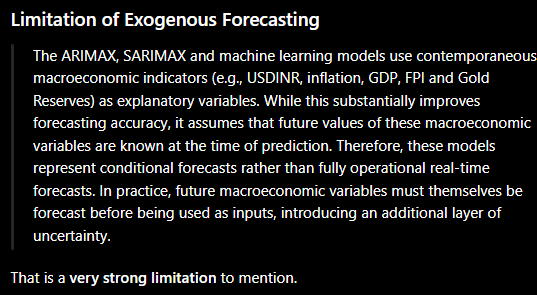

In [ ]:
import pandas as pd
import numpy as np

df_ml = df.copy()

df_ml["Lag1"] = df_ml["Gold_Price[/10gm]"].shift(1)
df_ml["Lag2"] = df_ml["Gold_Price[/10gm]"].shift(2)
df_ml["Lag3"] = df_ml["Gold_Price[/10gm]"].shift(3)
df_ml["Lag6"] = df_ml["Gold_Price[/10gm]"].shift(6)
df_ml["Lag12"] = df_ml["Gold_Price[/10gm]"].shift(12)


features = [

    "Lag1",
    "Lag2",
    "Lag3",
    "Lag6",
    "Lag12"

]

target = "Gold_Price[/10gm]"

data = df_ml[features + [target]].copy()

data = data.apply(pd.to_numeric, errors="coerce")

data = data.dropna()

train = data.iloc[:-24]

test = data.iloc[-24:]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

train_pred = model.predict(X_train)

forecast = model.predict(X_test)


from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

rmse = np.sqrt(mean_squared_error(y_test, forecast))

mae = mean_absolute_error(y_test, forecast)

mape = mean_absolute_percentage_error(y_test, forecast) * 100

r2 = r2_score(y_test, forecast)

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)
print("R²   :", r2)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    y_train.index,
    y_train,
    label="Train",
    lw=2
)

plt.plot(
    y_train.index,
    train_pred,
    label="Train Fitted",
    lw=2
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    lw=2
)

plt.plot(
    y_test.index,
    forecast,
    "--",
    label="Forecast",
    lw=2
)

plt.title("Multiple Linear Regression (Lags Only)")

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.grid(alpha=.3)

plt.legend()

plt.show()

In [ ]:
residuals = y_train - train_pred

plt.figure(figsize=(15,4))

plt.plot(
    y_train.index,
    residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residuals")

plt.grid(alpha=.3)

plt.show()

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    forecast
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(alpha=.3)

plt.show()

In [ ]:
coef_table = pd.DataFrame({

    "Feature": features,

    "Coefficient": model.coef_

})

coef_table.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

In [ ]:
forecasted_df = pd.read_excel("/content/ci_master_forecasted_24_27.xlsx")

In [ ]:
forecasted_df

In [ ]:
forecasted_df = forecasted_df.loc[:, ~forecasted_df.columns.str.contains("^Unnamed")]

In [ ]:
forecasted_df["Date"] = pd.to_datetime(forecasted_df["Date"])

In [ ]:
forecasted_df.set_index("Date", inplace=True)

In [ ]:
forecasted_df.sort_index(inplace=True)

In [ ]:
forecasted_df = forecasted_df.asfreq("MS")

In [ ]:
forecasted_df

# **Revised ARIMAX**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [ ]:
main_df = df.copy()
forecasted_df = forecasted_df.copy()

# The 'Date' column is already the datetime index of main_df from previous processing of df.
# main_df["Date"] = pd.to_datetime(main_df["Date"])

forecasted_df.index = pd.to_datetime(forecasted_df.index)

# The 'Date' column is already the datetime index of main_df.
# main_df.set_index("Date", inplace=True)

main_df = main_df.asfreq("MS")
forecasted_df = forecasted_df.asfreq("MS")

In [ ]:
target = "Gold_Price[/10gm]"

features = [

    "USDINR",

    "Inflation_YoY",

    "GDP_current_prices", # Corrected name

    "FPI_Net_INR_Crore",

    "Gold_Reserves_USD_mn", # Corrected name

    "Repo_Rate"

]

In [ ]:
data = main_df[
    [target] + features
].copy()

data = data.apply(
    pd.to_numeric,
    errors="coerce"
)

data = data.dropna()

In [ ]:
train = data.iloc[:-24]

test = data.iloc[-24:]

y_train = train[target]
y_test = test[target]

X_train = train[features]
X_test = test[features]

In [ ]:
print(train.index[0])
print(train.index[-1])

print(test.index[0])
print(test.index[-1])

In [ ]:
results = []

best_rmse = np.inf
best_order = None
best_model = None

In [ ]:
for p in range(4):

    for d in [1,2]:

        for q in range(4):

            try:

                model = SARIMAX(

                    y_train,

                    exog=X_train,

                    order=(p,d,q),

                    seasonal_order=(0,0,0,0),

                    enforce_stationarity=False,

                    enforce_invertibility=False

                )

                fit = model.fit(disp=False)

                pred = fit.forecast(

                    steps=len(test),

                    exog=X_test

                )

                rmse = np.sqrt(
                    mean_squared_error(
                        y_test,
                        pred
                    )
                )

                mae = mean_absolute_error(
                    y_test,
                    pred
                )

                mape = mean_absolute_percentage_error(
                    y_test,
                    pred
                )

                results.append([

                    (p,d,q),

                    fit.aic,

                    fit.bic,

                    rmse,

                    mae,

                    mape

                ])

                if rmse < best_rmse:

                    best_rmse = rmse

                    best_order = (p,d,q)

                    best_model = fit

            except:

                continue

In [ ]:
results = pd.DataFrame(

    results,

    columns=[

        "Order",

        "AIC",

        "BIC",

        "RMSE",

        "MAE",

        "MAPE"

    ]

)

results.sort_values(

    "RMSE"

).head(20)

In [ ]:
print(best_order)

print(best_rmse)

In [ ]:
model = SARIMAX(

    y_train,

    exog=X_train,

    order=best_order,

    seasonal_order=(0,0,0,0),

    enforce_stationarity=False,

    enforce_invertibility=False

)

fit = model.fit()

print(fit.summary())

In [ ]:
train_fit = fit.fittedvalues

forecast = fit.forecast(
    steps=len(test),
    exog=X_test
)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mae = mean_absolute_error(y_test, forecast)
mape = mean_absolute_percentage_error(y_test, forecast)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.4f}")

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train,
    label="Train",
    lw=2
)

plt.plot(
    train_fit,
    label="Train Fitted",
    lw=2
)

plt.plot(
    y_test,
    label="Actual",
    lw=2
)

plt.plot(
    y_test.index,
    forecast,
    "--r",
    label="Forecast",
    lw=2
)

plt.grid(alpha=.3)

plt.legend()

plt.title("ARIMAX Forecast")

plt.show()

In [ ]:
residuals = fit.resid

plt.figure(figsize=(16,4))

plt.plot(residuals)

plt.axhline(
    0,
    color="red",
    ls="--"
)

plt.grid(alpha=.3)

plt.title("Residuals")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=25,
    edgecolor="black"
)

plt.grid(alpha=.3)

plt.title("Residual Histogram")

plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=30
)

plt.grid(alpha=.3)

plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

lb

In [ ]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residuals)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

for label, value in zip(labels, arch_test):
    print(f"{label}: {value}")

In [ ]:
# Historical data

# Use history only until Dec 2023
data_final = data.loc[:'2023-12-01'].copy()

y_full = data_final[target]
X_full = data_final[features]

In [ ]:
final_model = SARIMAX(

    y_full,

    exog=X_full,

    order=best_order,

    seasonal_order=(0,0,0,0),

    enforce_stationarity=False,

    enforce_invertibility=False

)

final_fit = final_model.fit()

print(final_fit.summary())

In [ ]:
forecasted_df

In [ ]:
feature_base_names = {
    "USDINR": "USDINR",
    "Inflation_YoY": "Inflation",
    "GDP, current prices (Billions of U.S. dollars)": "GDP",
    "FPI_Net_INR_Crore": "FPI",
    "Gold_Reservs_USD_mn": "GoldReserve",
    "Repo_Rate": "Repo_Rate"
}

# Initialize an empty DataFrame for future_mean. This cell no longer populates future_mean directly.
# The actual population of future_mean will happen in a later cell by averaging future_lower and future_upper.
future_mean_initialized = pd.DataFrame(index=forecasted_df.index)

# The problematic loop and logic for creating future_mean has been removed from this cell
# as future_mean is intended to be created by averaging future_lower and future_upper.

In [ ]:
future_lower = forecasted_df[[
    "USDINR_Lower",
    "Repo_Rate_Lower",
    "GoldReserve_Lower",
    "GDP_Lower",
    "Inflation_Lower",
    "FPI_Lower"
]].copy()

future_lower.columns = [
    "USDINR",
    "Repo_Rate",
    "Gold_Reservs_USD_mn", # Corrected name to match training
    "GDP, current prices (Billions of U.S. dollars)", # Corrected name to match training
    "Inflation_YoY",
    "FPI_Net_INR_Crore"
]

In [ ]:
future_upper = forecasted_df[[
    "USDINR_Upper",
    "Repo_Rate_Upper",
    "GoldReserve_Upper",
    "GDP_Upper",
    "Inflation_Upper",
    "FPI_Upper"
]].copy()

future_upper.columns = [
    "USDINR",
    "Repo_Rate",
    "Gold_Reservs_USD_mn", # Corrected name to match training
    "GDP, current prices (Billions of U.S. dollars)", # Corrected name to match training
    "Inflation_YoY",
    "FPI_Net_INR_Crore"
]

In [ ]:
future_mean = (future_lower + future_upper) / 2

In [ ]:
future_mean.head()

In [ ]:
print(future_lower.shape)
print(future_mean.shape)
print(future_upper.shape)

In [ ]:
features = [
    "USDINR",
    "Inflation_YoY",
    "GDP, current prices (Billions of U.S. dollars)", # Using the name the model was trained with
    "FPI_Net_INR_Crore",
    "Gold_Reservs_USD_mn", # Using the name the model was trained with (including the 's' typo)
    "Repo_Rate"
]

forecast_mean = final_fit.get_forecast(
    steps=len(future_mean),
    exog=future_mean[features]
)

In [ ]:
future_mean[features].isna().sum()

In [ ]:
future_mean

In [ ]:
forecast_mean = final_fit.get_forecast(

    steps=len(future_mean),

    exog=future_mean[features]

)

In [ ]:
gold_mean = forecast_mean.predicted_mean

gold_ci = forecast_mean.conf_int()

gold_lower = gold_ci.iloc[:,0]

gold_upper = gold_ci.iloc[:,1]

In [ ]:
gold_forecast = pd.DataFrame({

    "Gold_Forecast": gold_mean,

    "Lower_CI": gold_lower,

    "Upper_CI": gold_upper

})

gold_forecast.head()

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    y_full,
    lw=2,
    label="Historical Gold Price"
)

plt.plot(
    gold_mean,
    '--r',
    lw=2,
    label="Forecast"
)

plt.fill_between(

    gold_mean.index,

    gold_lower,

    gold_upper,

    alpha=.25,

    label="95% Confidence Interval"

)

plt.axvline(
    x=y_full.index[-1],
    color="black",
    linestyle="--",
    lw=1.5,
    label="Forecast Start"
)

plt.grid(alpha=.15)

plt.legend()

plt.title("Gold Price Forecast using ARIMAX")

plt.show()

In [ ]:
gold_forecast

# **Revised SARIMAX**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)

In [ ]:
target = "Gold_Price[/10gm]"

features = [

    "USDINR",

    "Inflation_YoY",

    "GDP, current prices (Billions of U.S. dollars)",

    "FPI_Net_INR_Crore",

    "Gold_Reservs_USD_mn",

    "Repo_Rate"

]

data = main_df[
    [target] + features
].copy()

data = data.apply(
    pd.to_numeric,
    errors="coerce"
)

data = data.dropna()

In [ ]:
train = data.loc[:'2023-12']

test = data.loc['2024-01':'2025-12']

y_train = train[target]
y_test = test[target]

X_train = train[features]
X_test = test[features]

In [ ]:
results = []

best_rmse = np.inf

best_order = None
best_seasonal = None

In [ ]:
# for p in range(3):

#     for d in [1,2]:

#         for q in range(3):

#             for P in range(2):

#                 for D in range(2):

#                     for Q in range(2):

#                         try:

#                             model = SARIMAX(

#                                 y_train,

#                                 exog=X_train,

#                                 order=(p,d,q),

#                                 seasonal_order=(P,D,Q,12),

#                                 enforce_stationarity=False,

#                                 enforce_invertibility=False

#                             )

#                             fit = model.fit(disp=False)

#                             pred = fit.forecast(

#                                 steps=len(y_test),

#                                 exog=X_test

#                             )

#                             rmse = np.sqrt(

#                                 mean_squared_error(

#                                     y_test,

#                                     pred

#                                 )

#                             )

#                             mae = mean_absolute_error(

#                                 y_test,

#                                 pred

#                             )

#                             mape = mean_absolute_percentage_error(

#                                 y_test,

#                                 pred

#                             )

#                             results.append([

#                                 (p,d,q),

#                                 (P,D,Q,12),

#                                 fit.aic,

#                                 fit.bic,

#                                 rmse,

#                                 mae,

#                                 mape

#                             ])

#                             if rmse < best_rmse:

#                                 best_rmse = rmse

#                                 best_order = (p,d,q)

#                                 best_seasonal = (P,D,Q,12)

#                         except:

#                             continue

In [ ]:
# results = pd.DataFrame(

#     results,

#     columns=[

#         "Order",

#         "Seasonal",

#         "AIC",

#         "BIC",

#         "RMSE",

#         "MAE",

#         "MAPE"

#     ]

# )

# results.sort_values(

#     "RMSE"

# ).head(20)

In [ ]:
# print(best_order)

# print(best_seasonal)

# print(best_rmse)

In [ ]:
model = SARIMAX(

    y_train,

    exog=X_train,

    order=(0,2,0),

    seasonal_order=(1,1,0,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

fit = model.fit()

print(fit.summary())

In [ ]:
train_fit = fit.fittedvalues

forecast = fit.forecast(

    steps=len(y_test),

    exog=X_test

)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test,forecast))

mae = mean_absolute_error(y_test,forecast)

mape = mean_absolute_percentage_error(y_test,forecast)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.4f}")

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(

    y_train,

    label="Train",

    lw=2

)

plt.plot(

    train_fit,

    label="Train Fitted",

    lw=2

)

plt.plot(

    y_test,

    label="Actual",

    lw=2

)

plt.plot(

    y_test.index,

    forecast,

    '--r',

    label="Forecast",

    lw=2

)

plt.grid(alpha=.3)

plt.legend()

plt.title("SARIMAX Forecast")

plt.show()

In [ ]:
residuals = fit.resid

In [ ]:
plt.figure(figsize=(16,4))

plt.plot(residuals)

plt.axhline(
    0,
    color='red',
    ls='--'
)

plt.grid(alpha=.3)

plt.title("SARIMAX Residuals")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=30,
    edgecolor='black'
)

plt.grid(alpha=.3)

plt.title("Residual Histogram")

plt.show()

In [ ]:
plot_acf(
    residuals,
    lags=30
)

plt.grid(alpha=.3)

plt.show()

In [ ]:
lb = acorr_ljungbox(

    residuals,

    lags=[10],

    return_df=True

)

lb

In [ ]:
arch = het_arch(residuals)

labels = [

    "LM Statistic",

    "LM p-value",

    "F Statistic",

    "F p-value"

]

for l,v in zip(labels,arch):

    print(f"{l}: {v}")

In [ ]:
!pip install arch

In [ ]:
from arch import arch_model

In [ ]:
residuals = fit.resid.copy()

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(residuals)

plt.axhline(0,color='red',ls='--')

plt.grid(alpha=.3)

plt.title("SARIMAX Residuals")

plt.show()

In [ ]:
garch = arch_model(

    residuals,

    mean='Zero',

    vol='GARCH',

    p=1,

    q=1,

    dist='normal'

)

garch_fit = garch.fit()

print(garch_fit.summary())

In [ ]:
std_resid = garch_fit.std_resid

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(std_resid)

plt.axhline(0,color='red',ls='--')

plt.grid(alpha=.3)

plt.title("Standardized Residuals")

plt.show()

In [ ]:
volatility = garch_fit.conditional_volatility

In [ ]:
plt.figure(figsize=(15,4))

plt.plot(volatility)

plt.grid(alpha=.3)

plt.title("Estimated Conditional Volatility")

plt.show()

In [ ]:
lb = acorr_ljungbox(

    std_resid,

    lags=[10],

    return_df=True

)

lb

In [ ]:
arch = het_arch(std_resid)

labels = [

    "LM Statistic",

    "LM p-value",

    "F Statistic",

    "F p-value"

]

for l,v in zip(labels,arch):

    print(f"{l}: {v}")

# **Random Forest**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [ ]:
target = "Gold_Price[/10gm]"

features = [

    "USDINR",

    "Inflation_YoY",

    "GDP, current prices (Billions of U.S. dollars)",

    "FPI_Net_INR_Crore",

    "Gold_Reservs_USD_mn",

    "Repo_Rate"

]

rf_df = main_df[[target] + features].copy()

rf_df = rf_df.apply(pd.to_numeric, errors="coerce")

In [ ]:
lags = [1,2,3,6,12]

for lag in lags:

    rf_df[f"Gold_Lag_{lag}"] = rf_df[target].shift(lag)

In [ ]:
rf_df = rf_df.dropna()

In [ ]:
rf_features = features + [

    "Gold_Lag_1",

    "Gold_Lag_2",

    "Gold_Lag_3",

    "Gold_Lag_6",

    "Gold_Lag_12"

]

In [ ]:
train = rf_df.loc[:'2023-12']

test = rf_df.loc['2024-01':'2025-12']

X_train = train[rf_features]

y_train = train[target]

X_test = test[rf_features]

y_test = test[target]

In [ ]:
rf = RandomForestRegressor(

    n_estimators=500,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train,

    y_train

)

In [ ]:
train_pred = rf.predict(X_train)

forecast = rf.predict(X_test)

In [ ]:
rmse = np.sqrt(

    mean_squared_error(

        y_test,

        forecast

    )

)

mae = mean_absolute_error(

    y_test,

    forecast

)

mape = mean_absolute_percentage_error(

    y_test,

    forecast

)

print(f"RMSE : {rmse:.2f}")

print(f"MAE  : {mae:.2f}")

print(f"MAPE : {mape:.4f}")

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(

    y_train,

    lw=2,

    label="Train"

)

plt.plot(

    train.index,

    train_pred,

    lw=2,

    label="Train Fitted"

)

plt.plot(

    y_test,

    lw=2,

    label="Actual"

)

plt.plot(

    test.index,

    forecast,

    '--r',

    lw=2,

    label="Forecast"

)

plt.grid(alpha=.3)

plt.legend()

plt.title("Random Forest Forecast")

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": rf_features,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.grid(alpha=.3)

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# **XGBoost**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
target = "Gold_Price[/10gm]"

features = [

    "USDINR",

    "Inflation_YoY",

    "GDP, current prices (Billions of U.S. dollars)",

    "FPI_Net_INR_Crore",

    "Gold_Reservs_USD_mn",

    "Repo_Rate"

]

xgb_df = main_df[[target]+features].copy()

xgb_df = xgb_df.apply(
    pd.to_numeric,
    errors="coerce"
)

In [ ]:
lags = [1,2,3,6,12]

for lag in lags:

    xgb_df[f"Gold_Lag_{lag}"] = xgb_df[target].shift(lag)

xgb_df.dropna(inplace=True)

In [ ]:
xgb_features = features + [

    "Gold_Lag_1",

    "Gold_Lag_2",

    "Gold_Lag_3",

    "Gold_Lag_6",

    "Gold_Lag_12"

]

In [ ]:
train = xgb_df.loc[:'2023-12']

test = xgb_df.loc['2024-01':'2025-12']

X_train = train[xgb_features]

y_train = train[target]

X_test = test[xgb_features]

y_test = test[target]

In [ ]:
xgb = XGBRegressor(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42

)

xgb.fit(

    X_train,

    y_train

)

In [ ]:
train_pred = xgb.predict(X_train)

forecast = xgb.predict(X_test)

In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast
    )
)

mae = mean_absolute_error(
    y_test,
    forecast
)

mape = mean_absolute_percentage_error(
    y_test,
    forecast
)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.4f}")

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(

    y_train,

    label="Train",

    lw=2

)

plt.plot(

    train.index,

    train_pred,

    label="Train Fitted",

    lw=2

)

plt.plot(

    y_test,

    label="Actual",

    lw=2

)

plt.plot(

    test.index,

    forecast,

    '--r',

    lw=2,

    label="Forecast"

)

plt.grid(alpha=.3)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature":xgb_features,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(

    importance.Feature,

    importance.Importance

)

plt.gca().invert_yaxis()

plt.grid(alpha=.3)

plt.title("XGBoost Feature Importance")

plt.show()

In [ ]:
residuals = y_train - train_pred

In [ ]:
plt.plot(residuals)